In [14]:
from src.database.data_loader import DataLoader

loader = DataLoader()

users = loader.load_users()
orders = loader.load_orders()
products = loader.load_products()
behaviors = loader.load_user_behaviors()

print(users.shape)
print(orders.shape)
print(products.shape)
print(behaviors.shape)

print(users.head())
print(orders.head())

E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\src\database\mysql_connect.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)
E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\src\database\mysql_connect.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)
E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\src\database\mysql_connect.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLA

(5000, 9)
(15000, 15)
(2000, 6)
(30000, 6)
   user_id age gender province city           registration_date member_level  \
0  U000001  35      男       湖北   深圳  2022-07-05 22:38:35.747288         铜牌会员   
1  U000002  30      男       浙江   厦门  2025-06-20 22:38:35.747288         普通会员   
2  U000003  37      女       云南   杭州  2025-12-14 22:38:35.747288         银牌会员   
3  U000004  44      男       江西   福州  2021-12-08 22:38:35.747288         铜牌会员   
4  U000005  30      男       河南   长沙  2024-07-20 22:38:35.747288         普通会员   

   account_balance  credit_score  
0          5761.97           611  
1          1690.84           674  
2           139.39           800  
3          1114.76           540  
4          2552.27           657  
    order_id  user_id product_id  quantity                  order_date  \
0  O00000001  U002593    P000771         5  2025-11-06 22:38:35.857691   
1  O00000002  U000258    P000230         5  2026-02-05 22:38:35.857691   
2  O00000003  U000290    P000801         1  

In [15]:
users.isnull().sum()

orders.isnull().sum()

products.isnull().sum()

behaviors.isnull().sum()

behavior_id         0
user_id             0
product_id          0
behavior_type       0
behavior_time       0
duration_seconds    0
dtype: int64

In [16]:
users.duplicated().sum()

orders.duplicated().sum()

products.duplicated().sum()

0

Text(0.5, 1.0, 'Order Amount Distribution')

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

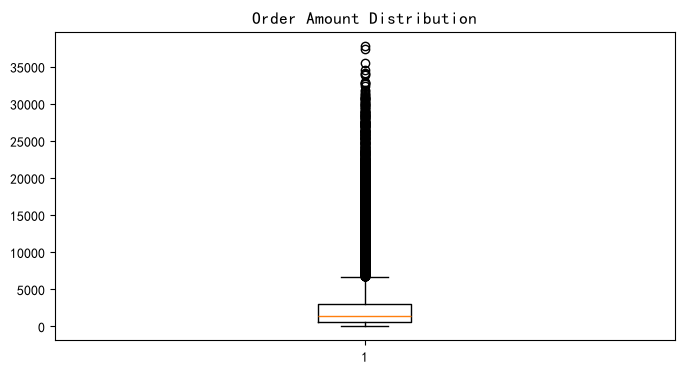

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
Q1 = orders["actual_payment"].quantile(0.25)
Q3 = orders["actual_payment"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = orders[
    (orders["actual_payment"] < lower)
    |
    (orders["actual_payment"] > upper)
]
plt.figure(figsize=(8,4))
plt.boxplot(
    orders["actual_payment"]
)
plt.title("Order Amount Distribution")

behavior_type
浏览    14930
点击     7665
收藏     4456
加购     2949
Name: count, dtype: int64


Text(0.5, 1.0, 'User Behavior Distribution')

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

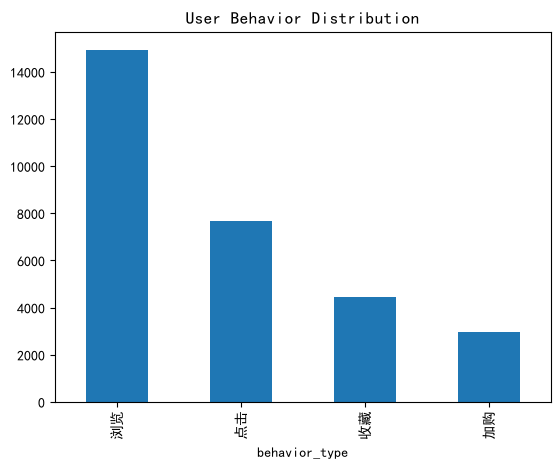

In [18]:
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常
behavior_count = (
behaviors["behavior_type"]
.value_counts()
)
print(behavior_count)
behavior_count.plot(
    kind="bar"
)
plt.title(
    "User Behavior Distribution"
)

In [19]:
avg_order_value = (

orders["actual_payment"].sum()

/

orders["user_id"].nunique()

)
print("客单价：", round(avg_order_value, 2))

客单价： 9733.5


In [20]:
# GMV
gmv = orders["actual_payment"].sum()

# 客单价
avg_order_value = (
    orders["actual_payment"].sum()
    /
    orders["user_id"].nunique()
)

# 支付率
paid_orders = orders[
    orders["order_status"].isin(
        [
            "已付款",
            "已发货",
            "已收货",
            "已完成"
        ]
    )
]

payment_rate = (
    len(paid_orders)
    /
    len(orders)
)

# 退款率
refund_orders = orders[
    orders["order_status"] == "已退款"
]

refund_rate = (
    len(refund_orders)
    /
    len(orders)
)

print("GMV:", round(gmv, 2))
print("客单价:", round(avg_order_value, 2))
print("支付率:", round(payment_rate * 100, 2), "%")
print("退款率:", round(refund_rate * 100, 2), "%")

GMV: 46165979.95
客单价: 9733.5
支付率: 85.1 %
退款率: 3.39 %


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

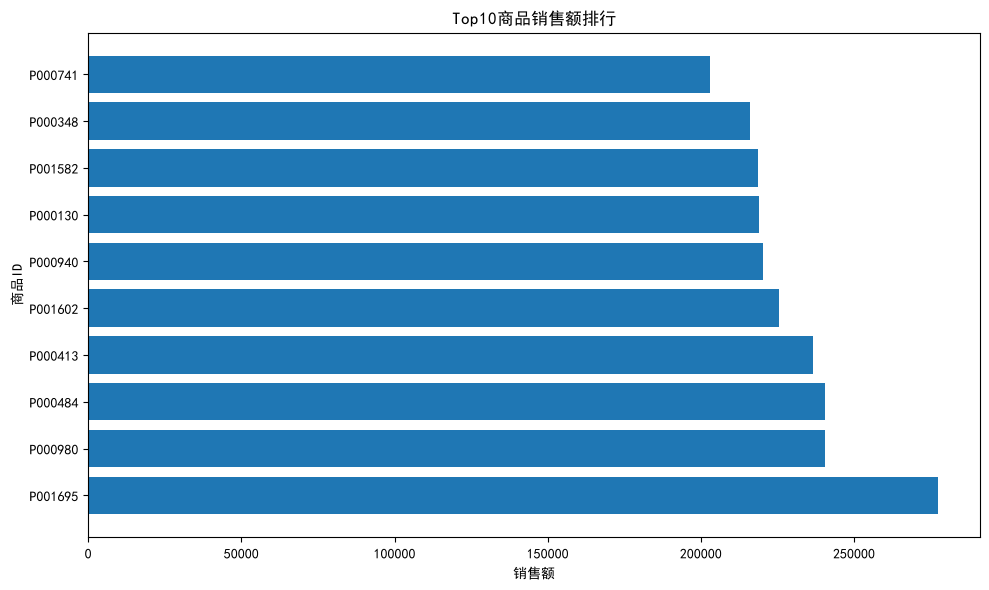

In [21]:
import matplotlib.pyplot as plt
import os

# 确保保存目录存在
os.makedirs("report/figures", exist_ok=True)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 计算Top10商品ID
top10 = (
    orders
    .groupby("product_id")["actual_payment"]
    .sum()
    .reset_index()
    .sort_values("actual_payment", ascending=False)
    .head(10)
)

# 柱状图（用 product_id 作为标签）
plt.figure(figsize=(10, 6))
plt.barh(top10["product_id"], top10["actual_payment"])
plt.title("Top10商品销售额排行")
plt.xlabel("销售额")
plt.ylabel("商品ID")

plt.tight_layout()
plt.savefig("report/figures/top_product.png", dpi=300)
plt.show()

In [22]:
abc = pd.read_csv(
    "outputs/processed/abc_result.csv"
)

top10 = abc.head(10)

print(
    top10[
        [
            "product_name",
            "actual_payment",
            "ABC"
        ]
    ]
)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/processed/abc_result.csv'

In [23]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,6))

plt.barh(
    top10["product_name"],
    top10["actual_payment"]
)


plt.title("Top10商品销售额排行")
plt.xlabel("销售额")
plt.ylabel("商品")

plt.tight_layout()

plt.savefig(
    "report/figures/top_product.png",
    dpi=300
)

plt.show()

KeyError: 'product_name'

<Figure size 1000x600 with 0 Axes>

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

项目根目录: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project
文件路径: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\data\processed\abc_result.csv


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

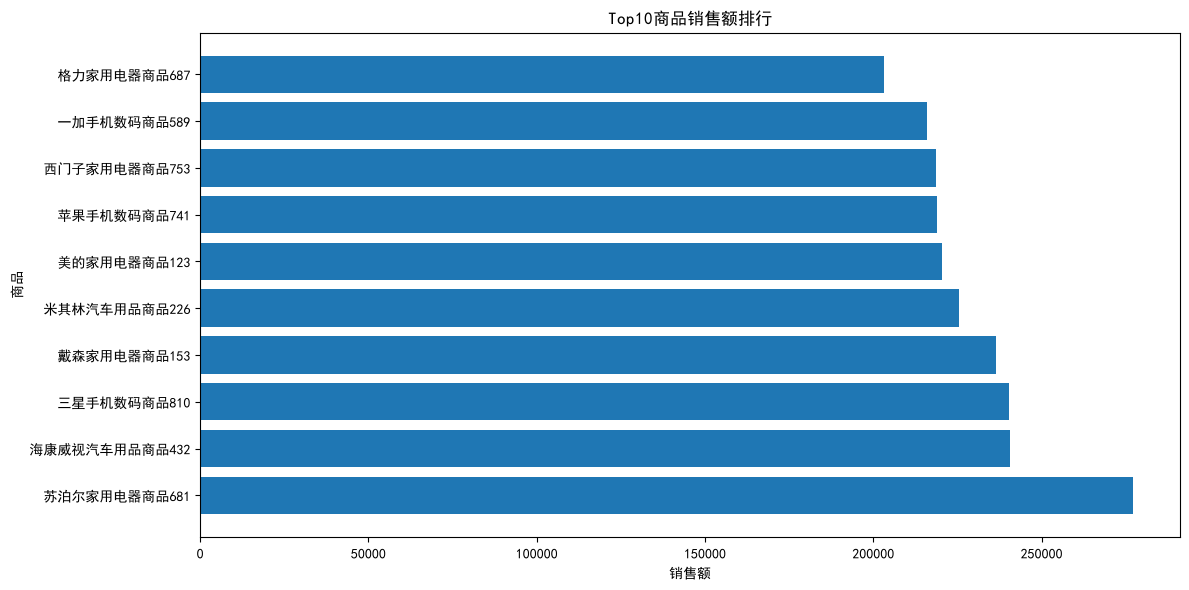

✅ 图表已保存至: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\reports\figures\top10_product.png


In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 获取当前工作目录（通常是 notebooks/ 或项目根目录）
current_dir = os.getcwd()

# 定义项目根目录的特征文件/文件夹
def find_project_root(start_dir):
    """从 start_dir 向上查找，直到找到包含 'README.md' 的目录"""
    current = os.path.abspath(start_dir)
    while True:
        if os.path.exists(os.path.join(current, "README.md")):
            return current
        parent = os.path.dirname(current)
        if parent == current:  # 到达系统根目录
            break
        current = parent
    return start_dir  # 如果找不到，返回原目录

project_root = find_project_root(current_dir)
print("项目根目录:", project_root)

# 构建文件路径
file_path = os.path.join(project_root, "data", "processed", "abc_result.csv")
print("文件路径:", file_path)

# 检查文件是否存在
if not os.path.exists(file_path):
    print(f"❌ 文件不存在: {file_path}")
    # 如果不存在，检查 data/processed 下有哪些文件
    data_processed = os.path.join(project_root, "data", "processed")
    if os.path.exists(data_processed):
        print("data/processed 目录内容:", os.listdir(data_processed))
    else:
        print("data/processed 目录不存在")
else:
    # 读取数据
    abc = pd.read_csv(file_path)
    top10 = abc.head(10)

    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 绘图
    plt.figure(figsize=(12, 6))
    plt.barh(top10["product_name"], top10["actual_payment"])
    plt.title("Top10商品销售额排行")
    plt.xlabel("销售额")
    plt.ylabel("商品")
    plt.tight_layout()

    # 保存图片（确保目录存在）
    figures_dir = os.path.join(project_root, "reports", "figures")
    os.makedirs(figures_dir, exist_ok=True)
    save_path = os.path.join(figures_dir, "top10_product.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"✅ 图表已保存至: {save_path}")

项目根目录: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project
文件路径: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\data\processed\rfm_result.csv
segment
普通用户     3794
高价值用户     949
Name: count, dtype: int64


<Axes: >

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

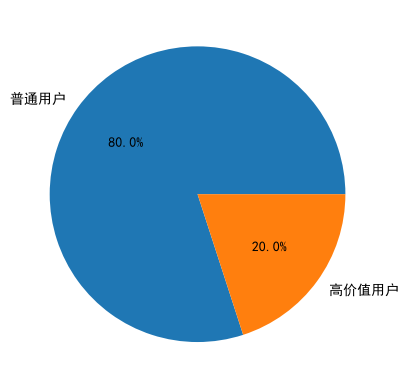

In [25]:
import os
import pandas as pd

def find_project_root(start_dir):
    """从当前目录向上查找，直到找到包含 'README.md' 的目录作为项目根目录"""
    current = os.path.abspath(start_dir)
    while True:
        if os.path.exists(os.path.join(current, "README.md")):
            return current
        parent = os.path.dirname(current)
        if parent == current:  # 到达系统根目录
            break
        current = parent
    return current  # 如果找不到，返回当前目录

# 获取项目根目录
project_root = find_project_root(os.getcwd())
print("项目根目录:", project_root)

# 构建完整路径
file_path = os.path.join(project_root, "data", "processed", "rfm_result.csv")
print("文件路径:", file_path)

# 读取文件
rfm = pd.read_csv(file_path)

segment_count = rfm["segment"].value_counts()
print(segment_count)
segment_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

In [ ]:
high_value = rfm[
    rfm["segment"]=="高价值用户"
]

high_value.head()

In [26]:
import pandas as pd
file_path = os.path.join(project_root, "data", "processed", "abc_result.csv")
print("文件路径:", file_path)

# 读取文件
abc= pd.read_csv(file_path)

print(abc.head())

文件路径: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\data\processed\abc_result.csv
  product_id  actual_payment   product_name category brand    price  \
0    P001695       277250.03   苏泊尔家用电器商品681     家用电器   苏泊尔  6464.30   
1    P000980       240474.59  海康威视汽车用品商品432     汽车用品  海康威视  7605.64   
2    P000484       240439.03    三星手机数码商品810     手机数码    三星  6532.11   
3    P000413       236567.17    戴森家用电器商品153     家用电器    戴森  6977.43   
4    P001602       225405.66   米其林汽车用品商品226     汽车用品   米其林  7787.60   

   sales_count  cum_ratio ABC  
0         3811   0.006006   A  
1         9325   0.011214   A  
2         4999   0.016423   A  
3         3568   0.021547   A  
4         7999   0.026429   A  


In [27]:
abc = abc.sort_values(
    "actual_payment",
    ascending=False
)

abc["cum_ratio"] = (

    abc["actual_payment"]

    .cumsum()

    /

    abc["actual_payment"].sum()

)
def classify_abc(x):

    if x <= 0.8:
        return "A"

    elif x <= 0.95:
        return "B"

    else:
        return "C"

abc["ABC"] = abc["cum_ratio"].apply(
    classify_abc
)

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

文件路径: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\data\processed\abc_result.csv


findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: 

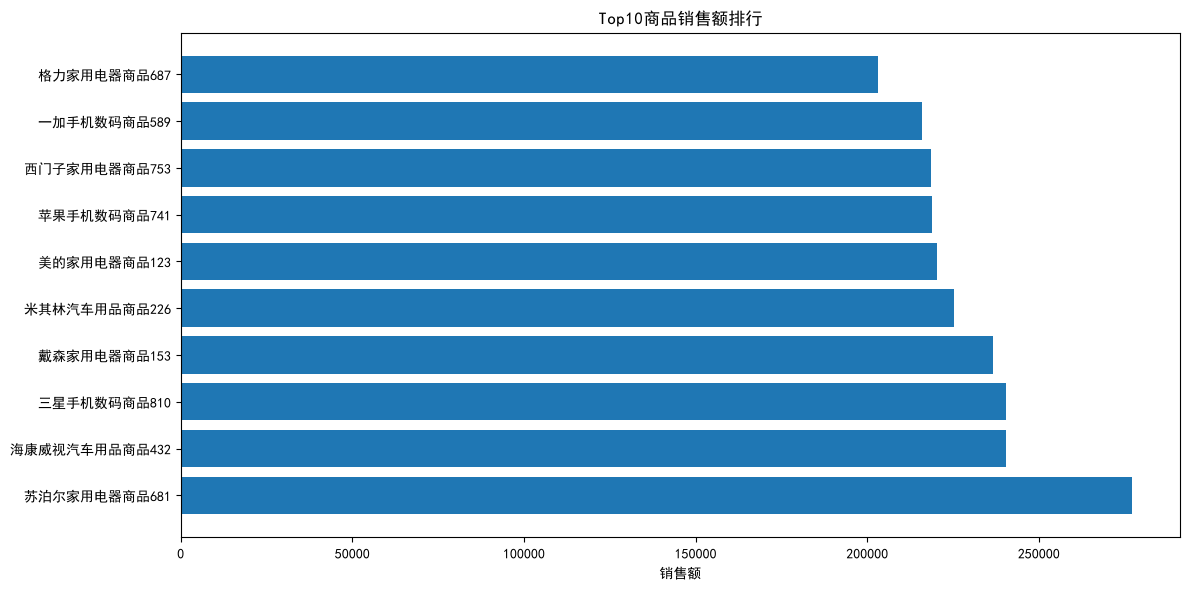

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

file_path = os.path.join(project_root, "data", "processed", "abc_result.csv")
print("文件路径:", file_path)

# 读取文件
abc= pd.read_csv(file_path)

top10 = abc.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["product_name"],
    top10["actual_payment"]
)

plt.title("Top10商品销售额排行")

plt.xlabel("销售额")

plt.tight_layout()

plt.savefig(
    "report/figures/top10_product.png",
    dpi=300
)

plt.show()

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

ABC
A    728
C    651
B    621
Name: count, dtype: int64


findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: 

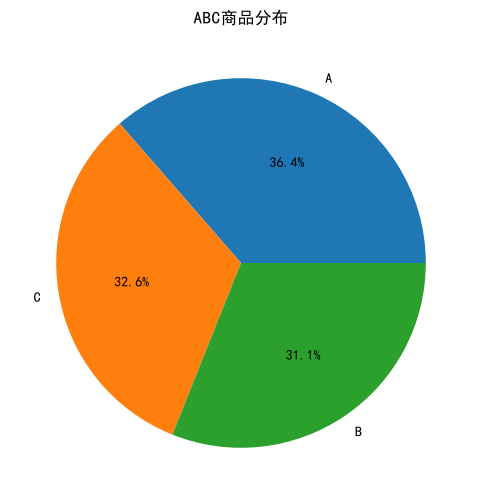

In [29]:
import pandas as pd

abc_count = (
    abc["ABC"]
    .value_counts()
)

print(abc_count)
plt.figure(figsize=(6,6))

plt.pie(
    abc_count,
    labels=abc_count.index,
    autopct="%1.1f%%"
)

plt.title("ABC商品分布")

plt.savefig(
    "report/figures/abc_distribution.png",
    dpi=300
)

plt.show()

In [30]:
file_path = os.path.join(project_root, "data", "processed", "abc_result.csv")
print("文件路径:", file_path)

# 读取文件
abc= pd.read_csv(file_path)

print(
    abc.head()
)

文件路径: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\data\processed\abc_result.csv
  product_id  actual_payment   product_name category brand    price  \
0    P001695       277250.03   苏泊尔家用电器商品681     家用电器   苏泊尔  6464.30   
1    P000980       240474.59  海康威视汽车用品商品432     汽车用品  海康威视  7605.64   
2    P000484       240439.03    三星手机数码商品810     手机数码    三星  6532.11   
3    P000413       236567.17    戴森家用电器商品153     家用电器    戴森  6977.43   
4    P001602       225405.66   米其林汽车用品商品226     汽车用品   米其林  7787.60   

   sales_count  cum_ratio ABC  
0         3811   0.006006   A  
1         9325   0.011214   A  
2         4999   0.016423   A  
3         3568   0.021547   A  
4         7999   0.026429   A  


In [31]:
import pandas as pd


abc_count = (
    abc["ABC"].value_counts()
)

print(abc_count)

ABC
A    728
C    651
B    621
Name: count, dtype: int64


findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

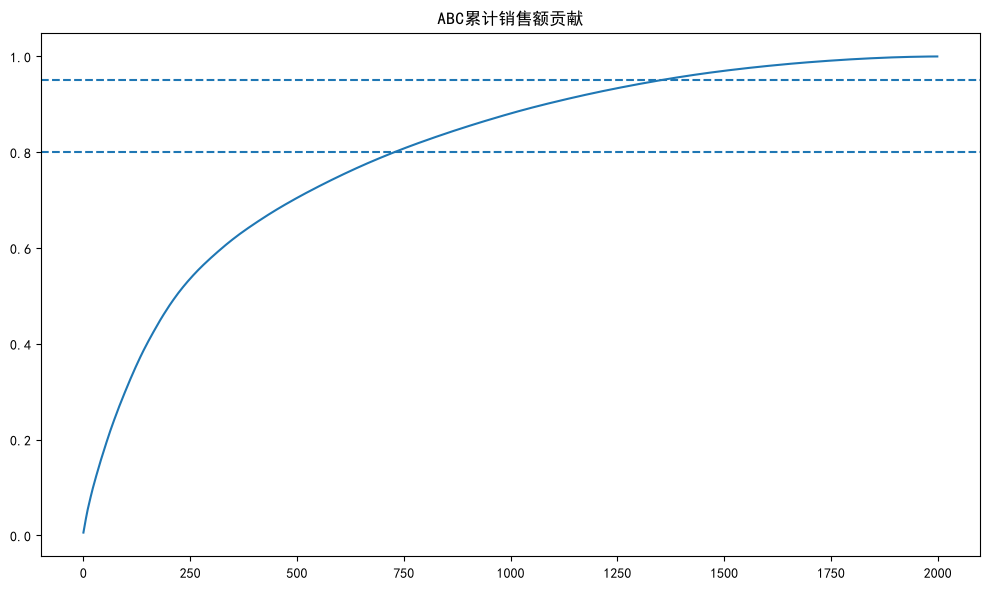

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(
    abc["cum_ratio"]
)

plt.axhline(
    0.8,
    linestyle="--"
)
plt.axhline(
    0.95,
    linestyle="--"
)
plt.title("ABC累计销售额贡献")
plt.tight_layout()
plt.savefig(
    "report/figures/abc_cum_ratio.png",
    dpi=300
)
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
X = churn_df.drop(
    columns=["user_id", "churn"]
)
y = churn_df["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

NameError: name 'churn_df' is not defined

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


NameError: name 'X_train' is not defined

In [35]:
users["registration_date"] = pd.to_datetime(
    users["registration_date"]
)

growth = (

    users.groupby(
        users["registration_date"]
        .dt.to_period("M")
    )

    ["user_id"]

    .count()

)

print(growth)

registration_date
2021-03     74
2021-04     86
2021-05     80
2021-06     82
2021-07     80
2021-08     86
2021-09     83
2021-10    104
2021-11     87
2021-12     75
2022-01     91
2022-02     79
2022-03     89
2022-04     95
2022-05     89
2022-06     93
2022-07     92
2022-08     75
2022-09     80
2022-10     86
2022-11     79
2022-12    102
2023-01     96
2023-02     75
2023-03     71
2023-04     88
2023-05     75
2023-06     79
2023-07    111
2023-08     85
2023-09     85
2023-10     90
2023-11     80
2023-12     91
2024-01     95
2024-02     70
2024-03     80
2024-04     85
2024-05    101
2024-06     91
2024-07     86
2024-08     79
2024-09     95
2024-10     91
2024-11     81
2024-12     64
2025-01     68
2025-02     63
2025-03     90
2025-04     90
2025-05     86
2025-06     88
2025-07     92
2025-08     93
2025-09     92
2025-10     81
2025-11     80
2025-12     67
2026-01     73
2026-02      6
Freq: M, Name: user_id, dtype: int64


In [36]:
rfm["segment"].value_counts()

segment
普通用户     3794
高价值用户     949
Name: count, dtype: int64

In [37]:
abc["ABC"].value_counts()


ABC
A    728
C    651
B    621
Name: count, dtype: int64

In [38]:
growth

registration_date
2021-03     74
2021-04     86
2021-05     80
2021-06     82
2021-07     80
2021-08     86
2021-09     83
2021-10    104
2021-11     87
2021-12     75
2022-01     91
2022-02     79
2022-03     89
2022-04     95
2022-05     89
2022-06     93
2022-07     92
2022-08     75
2022-09     80
2022-10     86
2022-11     79
2022-12    102
2023-01     96
2023-02     75
2023-03     71
2023-04     88
2023-05     75
2023-06     79
2023-07    111
2023-08     85
2023-09     85
2023-10     90
2023-11     80
2023-12     91
2024-01     95
2024-02     70
2024-03     80
2024-04     85
2024-05    101
2024-06     91
2024-07     86
2024-08     79
2024-09     95
2024-10     91
2024-11     81
2024-12     64
2025-01     68
2025-02     63
2025-03     90
2025-04     90
2025-05     86
2025-06     88
2025-07     92
2025-08     93
2025-09     92
2025-10     81
2025-11     80
2025-12     67
2026-01     73
2026-02      6
Freq: M, Name: user_id, dtype: int64

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

文件路径: E:\pycharm\Ecommerce_Growth_Analytics_Project\Ecommerce_Growth_Analytics_Project\data\processed\rfm_result.csv


FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/rfm_segment.png'

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

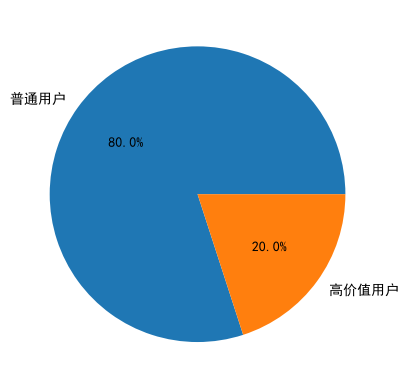

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import os
file_path = os.path.join(project_root, "data", "processed", "rfm_result.csv")
print("文件路径:", file_path)

# 读取文件
rfm= pd.read_csv(file_path)

rfm["segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.savefig(
    "reports/figures/rfm_segment.png"
)

plt.show()